# Классификация городских эпидемических волн по типу сети

Цель: обучить классификатор на synthetic SEIR-траекториях и применить его к городским недельным рядам. Модель отвечает, больше ли форма волны похожа на динамику на `barabasi_albert_graph` или на `watts_strogatz_graph`.

## Imports and config

In [35]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
SPLITS_DIR = DATA_DIR / 'splits'
CITY_DATA_PATH = DATA_DIR / 'indices_in_big_cities.csv'

GRAPH_LABELS = {
    'barabasi_albert_graph': 'barabasi_albert_graph',
    'watts_strogatz_graph': 'watts_strogatz_graph',
}
RANDOM_STATE = 42
MIN_SYNTHETIC_POINTS = 8
MIN_CITY_WAVE_POINTS = 6
CITY_START_YEAR = 2009

print(f'Project root: {ROOT}')

Project root: c:\Users\user\Desktop\projects\topology_influences_on_disease_spread


## Feature extraction

In [36]:
def _as_clean_float_array(y):
    arr = pd.to_numeric(pd.Series(y), errors='coerce').replace([np.inf, -np.inf], np.nan).to_numpy(dtype=float)
    arr = arr[~np.isnan(arr)]
    arr[arr < 0] = 0
    return arr


def normalize_curve(y):
    arr = _as_clean_float_array(y)
    if arr.size == 0:
        return arr
    max_value = np.nanmax(arr)
    if not np.isfinite(max_value) or max_value <= 0:
        return np.zeros_like(arr, dtype=float)
    return arr / max_value


def count_local_peaks(y, min_prominence=0.05):
    arr = np.asarray(y, dtype=float)
    if arr.size < 3:
        return 0
    peaks = 0
    for i in range(1, arr.size - 1):
        is_peak = arr[i] >= arr[i - 1] and arr[i] >= arr[i + 1]
        is_prominent = arr[i] - min(arr[i - 1], arr[i + 1]) >= min_prominence
        if is_peak and is_prominent:
            peaks += 1
    return peaks


def extract_curve_features(y):
    raw = _as_clean_float_array(y)
    n = int(raw.size)
    if n == 0:
        return {
            'n_points': 0,
            'raw_peak': 0.0,
            'peak_value': 0.0,
            'time_to_peak': 0.0,
            'duration': 0.0,
            'auc': 0.0,
            'max_growth': 0.0,
            'max_decline': 0.0,
            'width_at_half_max': 0.0,
            'asymmetry': 0.0,
            'early_slope': 0.0,
            'num_peaks': 0,
            'mean_value': 0.0,
            'std_value': 0.0,
        }

    arr = normalize_curve(raw)
    raw_peak = float(np.max(raw)) if raw.size else 0.0
    peak_idx = int(np.argmax(arr)) if arr.size else 0
    denom = max(n - 1, 1)
    time_to_peak = peak_idx / denom
    duration = float(np.sum(arr > 0.05) / n)
    auc = float(np.trapz(arr) / denom) if n > 1 else float(arr[0])

    diff = np.diff(arr) if n > 1 else np.array([0.0])
    max_growth = float(np.max(diff)) if diff.size else 0.0
    max_decline = float(abs(np.min(diff))) if diff.size else 0.0

    half_mask = arr >= 0.5
    if np.any(half_mask):
        half_positions = np.where(half_mask)[0]
        width_at_half_max = float((half_positions[-1] - half_positions[0] + 1) / n)
    else:
        width_at_half_max = 0.0

    left_area = float(np.trapz(arr[:peak_idx + 1])) if peak_idx > 0 else 0.0
    right_area = float(np.trapz(arr[peak_idx:])) if peak_idx < n - 1 else 0.0
    asymmetry = (right_area - left_area) / (right_area + left_area + 1e-12)

    early_window = max(3, min(n, int(np.ceil(n * 0.2))))
    x = np.arange(early_window, dtype=float)
    early_y = arr[:early_window]
    if early_window >= 2 and np.std(early_y) > 0:
        early_slope = float(np.polyfit(x, early_y, 1)[0])
    else:
        early_slope = 0.0

    return {
        'n_points': n,
        'raw_peak': raw_peak,
        'peak_value': float(np.max(arr)),
        'time_to_peak': float(time_to_peak),
        'duration': duration,
        'auc': auc,
        'max_growth': max_growth,
        'max_decline': max_decline,
        'width_at_half_max': width_at_half_max,
        'asymmetry': float(asymmetry),
        'early_slope': early_slope,
        'num_peaks': int(count_local_peaks(arr)),
        'mean_value': float(np.mean(arr)),
        'std_value': float(np.std(arr)),
    }


FEATURE_COLUMNS = list(extract_curve_features([0, 1, 2, 1]).keys())
FEATURE_COLUMNS

['n_points',
 'raw_peak',
 'peak_value',
 'time_to_peak',
 'duration',
 'auc',
 'max_growth',
 'max_decline',
 'width_at_half_max',
 'asymmetry',
 'early_slope',
 'num_peaks',
 'mean_value',
 'std_value']

## Load synthetic splits

In [37]:
def extract_graph_kind(relative_path):
    match = re.search(r'simulations[\\/]+([^\\/]+)[\\/]+', str(relative_path))
    return match.group(1) if match else None


def load_synthetic_split(split_name):
    split_dir = SPLITS_DIR / split_name
    index_path = split_dir / f'{split_name}_index.csv'
    if not index_path.exists():
        raise FileNotFoundError(index_path)

    index_df = pd.read_csv(index_path)
    records = []
    skipped = []

    for row in index_df.itertuples(index=False):
        relative_path = getattr(row, 'initial')
        graph_kind = extract_graph_kind(relative_path)
        if graph_kind not in GRAPH_LABELS:
            skipped.append({'path': relative_path, 'reason': f'unsupported graph_kind={graph_kind}'})
            continue

        file_name = Path(str(relative_path).replace('\\\\', '/')).name
        curve_path = split_dir / file_name
        if not curve_path.exists():
            skipped.append({'path': relative_path, 'reason': f'missing file {curve_path.name}'})
            continue

        curve_df = pd.read_csv(curve_path)
        if 'I' not in curve_df.columns:
            skipped.append({'path': relative_path, 'reason': 'missing I column'})
            continue

        curve = _as_clean_float_array(curve_df['I'])
        if curve.size < MIN_SYNTHETIC_POINTS or np.max(curve) <= 0:
            skipped.append({'path': relative_path, 'reason': 'too short or flat curve'})
            continue

        features = extract_curve_features(curve)
        features.update({
            'split': split_name,
            'label': GRAPH_LABELS[graph_kind],
            'graph_kind': graph_kind,
            'curve_path': str(curve_path),
            'source_relative_path': relative_path,
        })
        records.append(features)

    return pd.DataFrame(records), pd.DataFrame(skipped)


synthetic_parts = []
synthetic_skipped_parts = []
for split_name in ['train', 'val', 'test']:
    split_features, split_skipped = load_synthetic_split(split_name)
    synthetic_parts.append(split_features)
    synthetic_skipped_parts.append(split_skipped.assign(split=split_name))

synthetic_features = pd.concat(synthetic_parts, ignore_index=True)
synthetic_skipped = pd.concat(synthetic_skipped_parts, ignore_index=True)

print('Valid synthetic rows by split and class:')
display(synthetic_features.groupby(['split', 'label']).size().unstack(fill_value=0))
print(f'Skipped rows: {len(synthetic_skipped)}')
display(synthetic_skipped.head())

Valid synthetic rows by split and class:


label,barabasi_albert_graph,watts_strogatz_graph
split,,
test,10,2
train,32,6
val,8,2


Skipped rows: 0


,split


In [38]:
if synthetic_features.empty:
    raise ValueError('No valid synthetic trajectories were loaded.')

feature_matrix = synthetic_features[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
nan_counts = feature_matrix.isna().sum().sort_values(ascending=False)
print('NaN counts in synthetic feature matrix:')
display(nan_counts[nan_counts > 0])

display(synthetic_features.head())

NaN counts in synthetic feature matrix:


Series([], dtype: int64)

,n_points,raw_peak,peak_value,time_to_peak,duration,auc,max_growth,max_decline,width_at_half_max,asymmetry,early_slope,num_peaks,mean_value,std_value,split,label,graph_kind,curve_path,source_relative_path
0,150,456.0,1.0,0.724832,0.880000,0.538414,0.048246,0.043860,0.586667,-0.101088,0.002994,0,0.537018,0.365326,train,watts_strogatz_graph,watts_strogatz_graph,c:\Users\user\Desktop\projects\topology_influe...,simulations/watts_strogatz_graph/lam=16/seir_s...
1,150,2143.0,1.0,0.557047,0.826667,0.380161,0.037331,0.037331,0.340000,0.068499,0.002845,0,0.377766,0.332685,train,barabasi_albert_graph,barabasi_albert_graph,c:\Users\user\Desktop\projects\topology_influe...,simulations/barabasi_albert_graph/lam=4/seir_s...
2,150,487.0,1.0,0.731544,0.880000,0.522091,0.053388,0.053388,0.553333,-0.130462,0.003909,1,0.520821,0.349389,train,watts_strogatz_graph,watts_strogatz_graph,c:\Users\user\Desktop\projects\topology_influe...,simulations/watts_strogatz_graph/lam=16/seir_s...
3,150,486.0,1.0,0.738255,0.886667,0.499075,0.045267,0.039095,0.493333,-0.088268,0.003934,0,0.498025,0.355598,train,barabasi_albert_graph,barabasi_albert_graph,c:\Users\user\Desktop\projects\topology_influe...,simulations/barabasi_albert_graph/lam=4/seir_s...
4,150,377.0,1.0,0.778523,0.873333,0.477017,0.045093,0.047745,0.473333,-0.106044,0.003198,0,0.476905,0.382829,train,barabasi_albert_graph,barabasi_albert_graph,c:\Users\user\Desktop\projects\topology_influe...,simulations/barabasi_albert_graph/lam=4/seir_s...


## Train and evaluate classifiers

In [39]:
train_df = synthetic_features[synthetic_features['split'] == 'train'].copy()
val_df = synthetic_features[synthetic_features['split'] == 'val'].copy()
test_df = synthetic_features[synthetic_features['split'] == 'test'].copy()

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    if df.empty:
        raise ValueError(f'{name} split is empty after validation.')
    if df['label'].nunique() < 2:
        raise ValueError(f'{name} split has less than two classes.')

X_train, y_train = train_df[FEATURE_COLUMNS], train_df['label']
X_val, y_val = val_df[FEATURE_COLUMNS], val_df['label']
X_test, y_test = test_df[FEATURE_COLUMNS], test_df['label']

models = {
    'logistic_regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'random_forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )),
    ]),
}

model_scores = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    model_scores.append({
        'model': model_name,
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_f1_macro': f1_score(y_val, val_pred, average='macro'),
    })

model_scores = pd.DataFrame(model_scores).sort_values(['val_f1_macro', 'val_accuracy'], ascending=False)
display(model_scores)

best_model_name = model_scores.iloc[0]['model']
best_model = models[best_model_name]
print(f'Best model: {best_model_name}')

,model,val_accuracy,val_f1_macro
1,random_forest,0.8,0.444444
0,logistic_regression,0.7,0.411765


Best model: random_forest


Test accuracy: 0.8333333333333334
Test macro F1: 0.45454545454545453

Classification report:
                       precision    recall  f1-score   support

barabasi_albert_graph       0.83      1.00      0.91        10
 watts_strogatz_graph       0.00      0.00      0.00         2

             accuracy                           0.83        12
            macro avg       0.42      0.50      0.45        12
         weighted avg       0.69      0.83      0.76        12



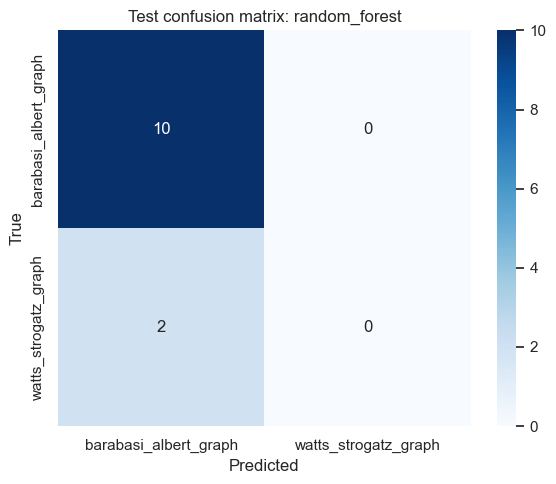

In [40]:
test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)

print('Test accuracy:', accuracy_score(y_test, test_pred))
print('Test macro F1:', f1_score(y_test, test_pred, average='macro'))
print('\nClassification report:')
print(classification_report(y_test, test_pred))

labels = list(best_model.classes_)
cm = confusion_matrix(y_test, test_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Test confusion matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Load city data

In [41]:
city_df = pd.read_csv(CITY_DATA_PATH, delimiter=';')
city_df['cld_year'] = pd.to_numeric(city_df['cld_year'], errors='coerce')
city_df['week_number'] = pd.to_numeric(city_df['week_number'], errors='coerce')
city_df['wd_total'] = pd.to_numeric(city_df['wd_total'], errors='coerce')
city_df['qty_total'] = pd.to_numeric(city_df['qty_total'], errors='coerce')
city_df = city_df[city_df['cld_year'] >= CITY_START_YEAR].copy()
city_df = city_df.sort_values(['town_name', 'cld_year', 'week_number']).reset_index(drop=True)

print(f'City start year: {CITY_START_YEAR}')
print(f'Rows: {len(city_df):,}')
print(f'Cities: {city_df["town_name"].nunique()}')
display(city_df.groupby('town_name').agg(
    rows=('wd_total', 'size'),
    non_missing_wd_total=('wd_total', lambda x: x.notna().sum()),
    first_year=('cld_year', 'min'),
    last_year=('cld_year', 'max'),
).reset_index())

City start year: 2009
Rows: 5,004
Cities: 12


,town_name,rows,non_missing_wd_total,first_year,last_year
0,Екатеринбург,417,365,2009,2016
1,Казань,417,365,2009,2016
2,Москва,417,365,2009,2016
3,Нижний_Новгород,417,365,2009,2016
4,Новосибирск,417,365,2009,2016
5,Омск,417,365,2009,2016
6,Пермь,417,365,2009,2016
7,Ростов-на-Дону,417,365,2009,2016
8,Самара,417,365,2009,2016
9,Санкт-Петербург,417,365,2009,2016


## Detect city waves

In [42]:
def prepare_city_series(group):
    group = group.sort_values(['cld_year', 'week_number']).copy()
    y = group['wd_total'].astype(float)
    population = group['qty_total'].replace(0, np.nan).astype(float)
    if population.notna().sum() > 0:
        y = y / population

    y = y.interpolate(limit_direction='both')
    smooth = y.rolling(window=5, center=True, min_periods=1).median()
    smooth = smooth.rolling(window=3, center=True, min_periods=1).mean()
    return smooth.to_numpy(dtype=float)


def find_city_waves(group, min_points=MIN_CITY_WAVE_POINTS):
    group = group.sort_values(['cld_year', 'week_number']).reset_index(drop=True).copy()
    y = prepare_city_series(group)
    valid = np.isfinite(y) & (y >= 0)
    if valid.sum() < min_points or np.nanmax(y[valid]) <= 0:
        return [], 'not enough non-empty observations'

    y = np.where(valid, y, np.nan)
    series = pd.Series(y).interpolate(limit_direction='both').to_numpy(dtype=float)
    threshold = max(np.nanquantile(series, 0.75), np.nanmean(series) + 0.5 * np.nanstd(series))
    min_distance = 10

    candidate_peaks = []
    for i in range(1, len(series) - 1):
        if series[i] >= threshold and series[i] >= series[i - 1] and series[i] >= series[i + 1]:
            if not candidate_peaks or i - candidate_peaks[-1] >= min_distance:
                candidate_peaks.append(i)
            elif series[i] > series[candidate_peaks[-1]]:
                candidate_peaks[-1] = i

    if not candidate_peaks:
        candidate_peaks = [int(np.nanargmax(series))]

    waves = []
    for peak_idx in candidate_peaks:
        peak_value = series[peak_idx]
        if peak_value <= 0:
            continue
        boundary_level = max(0.15 * peak_value, np.nanquantile(series, 0.35))

        start = peak_idx
        while start > 0 and series[start] > boundary_level:
            start -= 1

        end = peak_idx
        while end < len(series) - 1 and series[end] > boundary_level:
            end += 1

        if end - start + 1 < min_points:
            pad = max(0, (min_points - (end - start + 1)) // 2 + 1)
            start = max(0, start - pad)
            end = min(len(series) - 1, end + pad)

        wave = series[start:end + 1]
        if len(wave) >= min_points and np.nanmax(wave) > 0:
            waves.append({
                'start_idx': int(start),
                'end_idx': int(end),
                'peak_idx': int(peak_idx),
                'curve': wave,
                'start_year': int(group.loc[start, 'cld_year']),
                'start_week': int(group.loc[start, 'week_number']),
                'end_year': int(group.loc[end, 'cld_year']),
                'end_week': int(group.loc[end, 'week_number']),
                'peak_year': int(group.loc[peak_idx, 'cld_year']),
                'peak_week': int(group.loc[peak_idx, 'week_number']),
            })

    return waves, None


city_wave_records = []
city_wave_curves = []
city_wave_issues = []

for city, group in city_df.groupby('town_name'):
    waves, issue = find_city_waves(group)
    if issue:
        city_wave_issues.append({'city': city, 'issue': issue})
        continue
    for wave_id, wave in enumerate(waves, start=1):
        features = extract_curve_features(wave['curve'])
        features.update({
            'city': city,
            'wave_id': wave_id,
            'start_year': wave['start_year'],
            'start_week': wave['start_week'],
            'end_year': wave['end_year'],
            'end_week': wave['end_week'],
            'peak_year': wave['peak_year'],
            'peak_week': wave['peak_week'],
        })
        city_wave_records.append(features)
        city_wave_curves.append({
            'city': city,
            'wave_id': wave_id,
            'curve': wave['curve'],
        })

city_waves = pd.DataFrame(city_wave_records)
city_wave_issues = pd.DataFrame(city_wave_issues)

print(f'Detected city waves: {len(city_waves)}')
if not city_waves.empty:
    display(city_waves.groupby('city').size().rename('n_waves').reset_index())
if not city_wave_issues.empty:
    display(city_wave_issues)

Detected city waves: 137


,city,n_waves
0,Екатеринбург,16
1,Казань,9
2,Москва,10
3,Нижний_Новгород,13
4,Новосибирск,12
5,Омск,13
6,Пермь,10
7,Ростов-на-Дону,9
8,Самара,8
9,Санкт-Петербург,12


## Classify city waves

In [43]:
if city_waves.empty:
    raise ValueError('No city waves were detected.')

city_X = city_waves[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
city_pred = best_model.predict(city_X)
city_proba = best_model.predict_proba(city_X)
class_to_index = {label: idx for idx, label in enumerate(best_model.classes_)}

city_results = city_waves[['city', 'wave_id', 'start_year', 'start_week', 'end_year', 'end_week', 'peak_year', 'peak_week']].copy()
city_results['predicted_class'] = city_pred
city_results['ba_probability'] = city_proba[:, class_to_index['barabasi_albert_graph']]
city_results['watts_probability'] = city_proba[:, class_to_index['watts_strogatz_graph']]
city_results['confidence'] = city_proba.max(axis=1)

display(city_results.sort_values(['city', 'wave_id']).head(30))

city_summary = city_results.groupby('city').agg(
    n_waves=('wave_id', 'count'),
    ba_like_share=('ba_probability', lambda x: np.mean(x >= 0.5)),
    watts_like_share=('watts_probability', lambda x: np.mean(x >= 0.5)),
    mean_ba_probability=('ba_probability', 'mean'),
    mean_watts_probability=('watts_probability', 'mean'),
    mean_confidence=('confidence', 'mean'),
).reset_index().sort_values('mean_ba_probability', ascending=False)

display(city_summary)

,city,wave_id,start_year,start_week,end_year,end_week,peak_year,peak_week,predicted_class,ba_probability,watts_probability,confidence
0,Екатеринбург,1,2009,4,2009,13,2009,9,barabasi_albert_graph,0.865951,0.134049,0.865951
1,Екатеринбург,2,2009,42,2010,19,2009,46,barabasi_albert_graph,0.732320,0.267680,0.732320
2,Екатеринбург,3,2009,42,2010,19,2010,7,barabasi_albert_graph,0.732320,0.267680,0.732320
3,Екатеринбург,4,2010,36,2011,18,2011,7,barabasi_albert_graph,0.837304,0.162696,0.837304
4,Екатеринбург,5,2011,37,2012,19,2011,51,barabasi_albert_graph,0.881603,0.118397,0.881603
5,Екатеринбург,6,2011,37,2012,19,2012,11,barabasi_albert_graph,0.881603,0.118397,0.881603
6,Екатеринбург,7,2012,37,2013,18,2013,6,barabasi_albert_graph,0.890088,0.109912,0.890088
7,Екатеринбург,8,2014,2,2014,19,2014,10,barabasi_albert_graph,0.844917,0.155083,0.844917
8,Екатеринбург,9,2014,35,2015,19,2014,39,barabasi_albert_graph,0.882241,0.117759,0.882241
9,Екатеринбург,10,2014,35,2015,19,2015,7,barabasi_albert_graph,0.882241,0.117759,0.882241


,city,n_waves,ba_like_share,watts_like_share,mean_ba_probability,mean_watts_probability,mean_confidence
4,Новосибирск,12,1.0,0.0,0.886827,0.113173,0.886827
1,Казань,9,1.0,0.0,0.883251,0.116749,0.883251
10,Уфа,14,1.0,0.0,0.882014,0.117986,0.882014
9,Санкт-Петербург,12,1.0,0.0,0.878216,0.121784,0.878216
3,Нижний_Новгород,13,1.0,0.0,0.872786,0.127214,0.872786
11,Челябинск,11,1.0,0.0,0.872086,0.127914,0.872086
6,Пермь,10,1.0,0.0,0.871492,0.128508,0.871492
5,Омск,13,1.0,0.0,0.867721,0.132279,0.867721
8,Самара,8,1.0,0.0,0.866553,0.133447,0.866553
2,Москва,10,1.0,0.0,0.864256,0.135744,0.864256


## Visual summaries

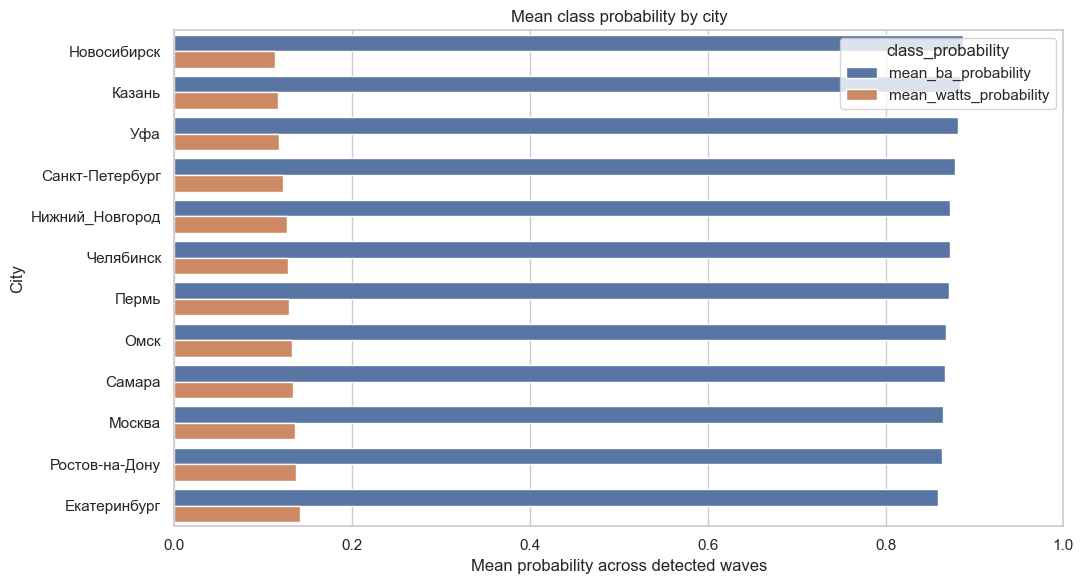

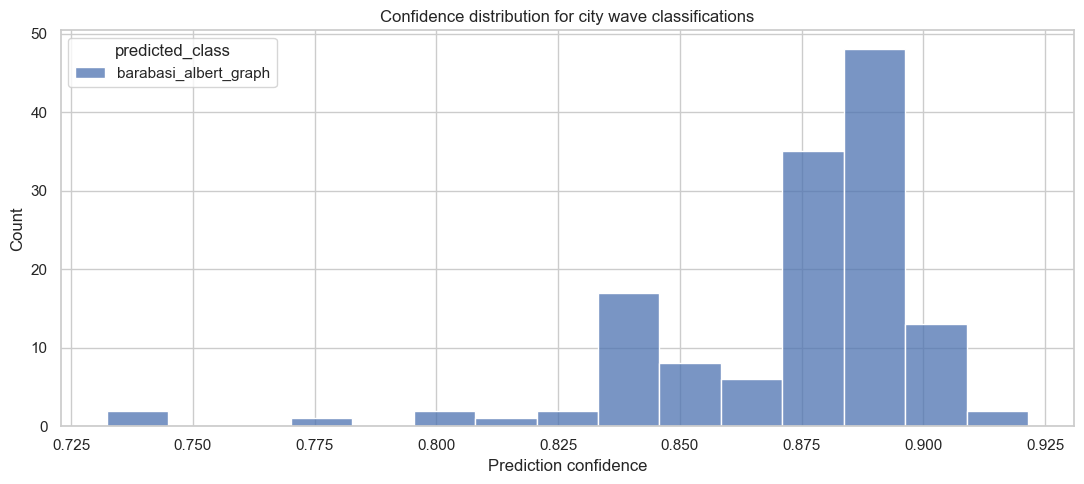

In [44]:
plt.figure(figsize=(11, 6))
plot_df = city_summary.melt(
    id_vars='city',
    value_vars=['mean_ba_probability', 'mean_watts_probability'],
    var_name='class_probability',
    value_name='mean_probability',
)
sns.barplot(data=plot_df, x='mean_probability', y='city', hue='class_probability')
plt.title('Mean class probability by city')
plt.xlabel('Mean probability across detected waves')
plt.ylabel('City')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.histplot(data=city_results, x='confidence', hue='predicted_class', bins=15, multiple='stack')
plt.title('Confidence distribution for city wave classifications')
plt.xlabel('Prediction confidence')
plt.tight_layout()
plt.show()

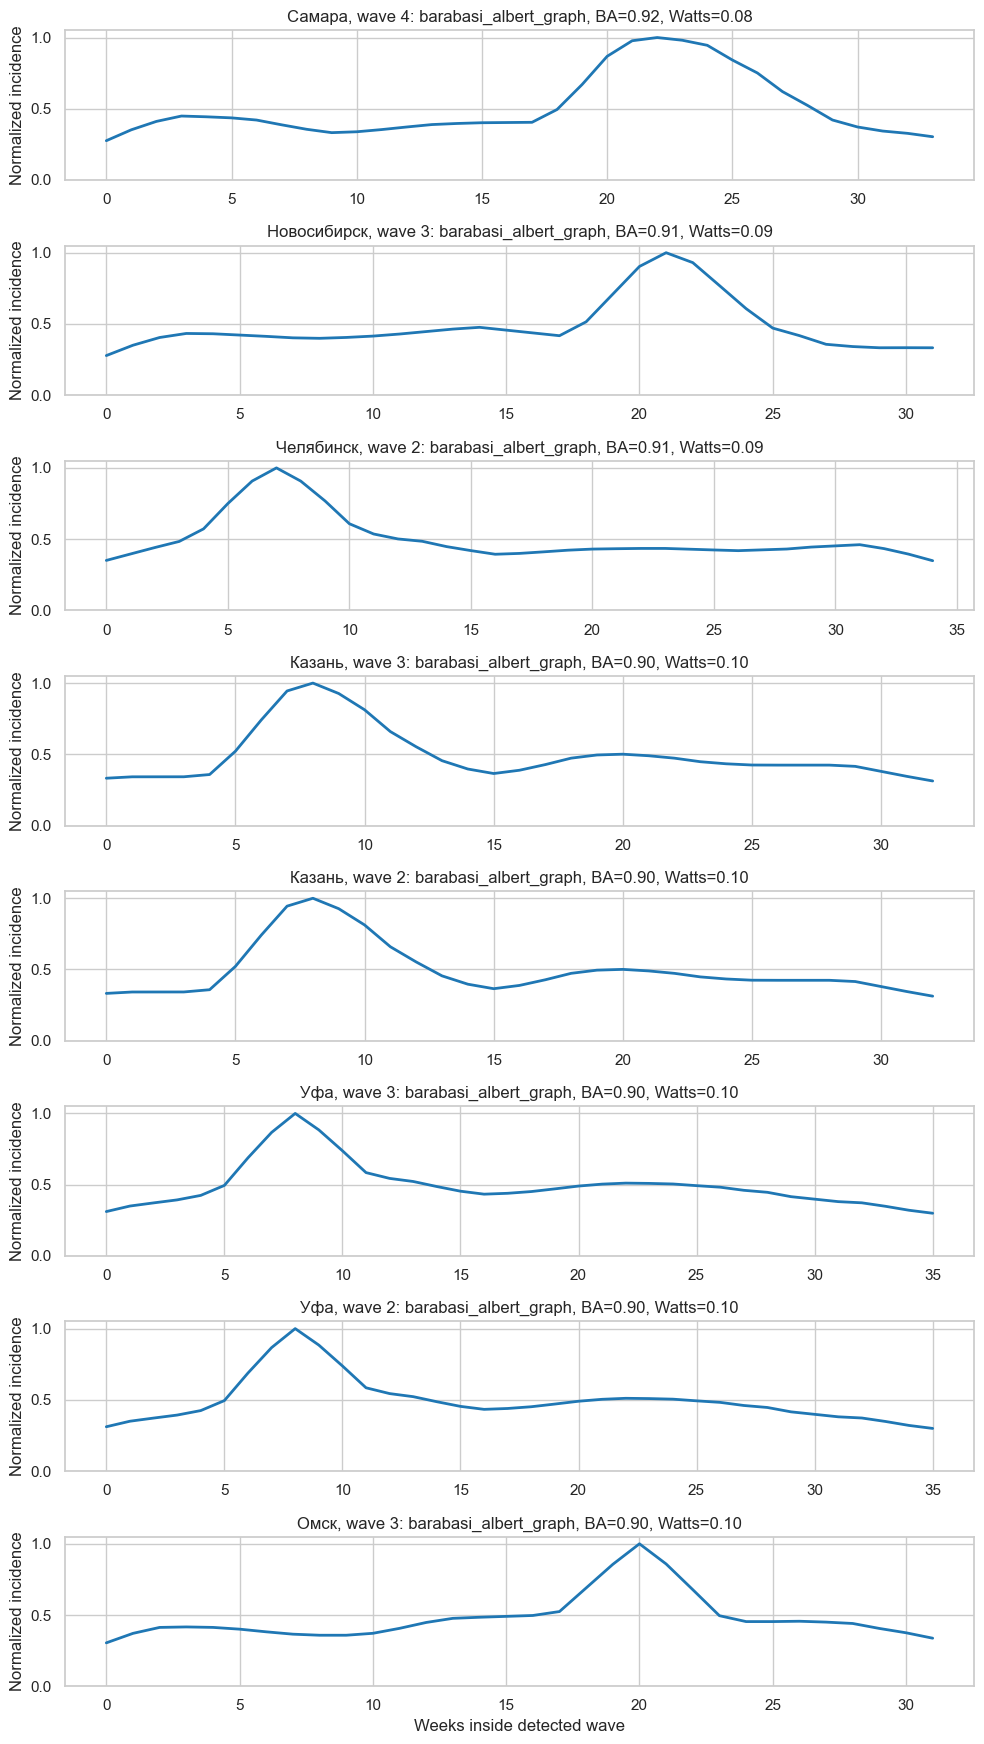

In [45]:
examples = city_results.sort_values('confidence', ascending=False).head(8)
curve_lookup = {(item['city'], item['wave_id']): item['curve'] for item in city_wave_curves}

n_examples = len(examples)
fig, axes = plt.subplots(n_examples, 1, figsize=(10, max(3, 2.2 * n_examples)), sharex=False)
if n_examples == 1:
    axes = [axes]

for ax, row in zip(axes, examples.itertuples(index=False)):
    curve = normalize_curve(curve_lookup[(row.city, row.wave_id)])
    ax.plot(curve, color='#1f77b4', linewidth=2)
    ax.set_ylim(0, 1.05)
    ax.set_title(
        f'{row.city}, wave {row.wave_id}: {row.predicted_class}, '
        f'BA={row.ba_probability:.2f}, Watts={row.watts_probability:.2f}'
    )
    ax.set_ylabel('Normalized incidence')

axes[-1].set_xlabel('Weeks inside detected wave')
plt.tight_layout()
plt.show()

## Notes for interpretation

- `best_model` is the selected classifier.
- `city_results` contains wave-level predictions.
- `city_summary` contains city-level aggregation.
- The current city-wave detector is intentionally simple and should be visually checked before drawing strong epidemiological conclusions.
- The indexed synthetic dataset is small and imbalanced. Treat this as a first research baseline; if the test report shows weak recall for one class, generate or index more balanced BA and Watts-Strogatz trajectories before making strong conclusions.